### 1. Extraccion de datos

In [1]:
# Librerías principales
import pandas as pd
import numpy as np

# Visualización
import matplotlib.pyplot as plt
import seaborn as sns

# Modelos y métricas
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, precision_score, recall_score

# Clustering
from sklearn.cluster import KMeans
from scipy.cluster.hierarchy import dendrogram, linkage

# Configuración visual
sns.set(style='whitegrid')

In [2]:
# Cargar dataset
gym = pd.read_csv('/datasets/gym_churn_us.csv')

# Mostrar tamaño del dataset
print(gym.shape)

# Mostrar primeras filas
gym.head()

(4000, 14)


,gender,Near_Location,Partner,Promo_friends,Phone,Contract_period,Group_visits,Age,Avg_additional_charges_total,Month_to_end_contract,Lifetime,Avg_class_frequency_total,Avg_class_frequency_current_month,Churn
0,1,1,1,1,0,6,1,29,14.227470,5.0,3,0.020398,0.000000,0
1,0,1,0,0,1,12,1,31,113.202938,12.0,7,1.922936,1.910244,0
2,0,1,1,0,1,1,0,28,129.448479,1.0,2,1.859098,1.736502,0
3,0,1,1,1,1,12,1,33,62.669863,12.0,2,3.205633,3.357215,0
4,1,1,1,1,1,1,0,26,198.362265,1.0,3,1.113884,1.120078,0


El dataset contiene 4000 observaciones y 14 columnas. Cada fila representa a un cliente del gimnasio e incluye información demográfica, características de la membresía, comportamiento de uso del gimnasio y la variable objetivo `Churn`, que indica si el cliente canceló o no.

Al revisar las primeras filas, se observa que todas las variables ya están en formato numérico, por lo que no es necesario aplicar codificación de variables categóricas en esta etapa.

### 2. Análisis exploratorio de datos — EDA

2.1 Revisar información general y valores ausentes

In [3]:
# Información general del dataset
gym.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 14 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   gender                             4000 non-null   int64  
 1   Near_Location                      4000 non-null   int64  
 2   Partner                            4000 non-null   int64  
 3   Promo_friends                      4000 non-null   int64  
 4   Phone                              4000 non-null   int64  
 5   Contract_period                    4000 non-null   int64  
 6   Group_visits                       4000 non-null   int64  
 7   Age                                4000 non-null   int64  
 8   Avg_additional_charges_total       4000 non-null   float64
 9   Month_to_end_contract              4000 non-null   float64
 10  Lifetime                           4000 non-null   int64  
 11  Avg_class_frequency_total          4000 non-null   float

In [4]:
# Revisar valores ausentes
gym.isna().sum()

gender                               0
Near_Location                        0
Partner                              0
Promo_friends                        0
Phone                                0
Contract_period                      0
Group_visits                         0
Age                                  0
Avg_additional_charges_total         0
Month_to_end_contract                0
Lifetime                             0
Avg_class_frequency_total            0
Avg_class_frequency_current_month    0
Churn                                0
dtype: int64

El dataset no contiene valores ausentes, ya que todas las columnas presentan 4000 registros no nulos. Esto permite trabajar directamente con los datos sin necesidad de imputar valores o eliminar observaciones por datos faltantes.

Además, todas las variables son numéricas: algunas son binarias, como `gender`, `Near_Location`, `Partner`, `Promo_friends`, `Phone`, `Group_visits` y `Churn`; mientras que otras son continuas o discretas, como `Age`, `Lifetime`, `Contract_period`, `Month_to_end_contract`, `Avg_class_frequency_total` y `Avg_class_frequency_current_month`.

In [5]:
# Estadísticas descriptivas
gym.describe()

,gender,Near_Location,Partner,Promo_friends,Phone,Contract_period,Group_visits,Age,Avg_additional_charges_total,Month_to_end_contract,Lifetime,Avg_class_frequency_total,Avg_class_frequency_current_month,Churn
count,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000
mean,0.510250,0.845250,0.486750,0.308500,0.903500,4.681250,0.412250,29.184250,146.943728,4.322750,3.724750,1.879020,1.767052,0.265250
std,0.499957,0.361711,0.499887,0.461932,0.295313,4.549706,0.492301,3.258367,96.355602,4.191297,3.749267,0.972245,1.052906,0.441521
min,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,18.000000,0.148205,1.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,1.000000,0.000000,0.000000,1.000000,1.000000,0.000000,27.000000,68.868830,1.000000,1.000000,1.180875,0.963003,0.000000
50%,1.000000,1.000000,0.000000,0.000000,1.000000,1.000000,0.000000,29.000000,136.220159,1.000000,3.000000,1.832768,1.719574,0.000000
75%,1.000000,1.000000,1.000000,1.000000,1.000000,6.000000,1.000000,31.000000,210.949625,6.000000,5.000000,2.536078,2.510336,1.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,12.000000,1.000000,41.000000,552.590740,12.000000,31.000000,6.023668,6.146783,1.000000


Las estadísticas descriptivas muestran que el perfil promedio del cliente tiene aproximadamente 29 años, vive o trabaja cerca del gimnasio en la mayoría de los casos y tiene una frecuencia media de visitas cercana a 1.9 veces por semana.

El periodo promedio de contrato es de 4.68 meses, aunque la mediana es de 1 mes, lo cual indica que una parte importante de los usuarios tiene contratos cortos. El tiempo promedio desde la primera visita (`Lifetime`) es de 3.72 meses, por lo que muchos clientes aún se encuentran en una etapa temprana de relación con el gimnasio.

También se observa que aproximadamente el 41% de los clientes participa en clases grupales y cerca del 49% trabaja en una empresa asociada. Estos factores pueden ser relevantes para analizar la retención.

2.2 Valores promedio por cancelación

Aquí vamos a comparar clientes que se quedaron vs clientes que se fueron.

In [6]:
# Valores promedio por grupo: 0 = se quedó, 1 = canceló
gym.groupby('Churn').mean()

,gender,Near_Location,Partner,Promo_friends,Phone,Contract_period,Group_visits,Age,Avg_additional_charges_total,Month_to_end_contract,Lifetime,Avg_class_frequency_total,Avg_class_frequency_current_month
Churn,,,,,,,,,,,,,
0,0.510037,0.873086,0.534195,0.353522,0.903709,5.747193,0.464103,29.976523,158.445715,5.283089,4.711807,2.024876,2.027882
1,0.510839,0.768143,0.355325,0.183789,0.902922,1.728558,0.268615,26.989632,115.082899,1.662582,0.990575,1.474995,1.044546


Al comparar los promedios entre clientes que permanecieron activos y clientes que cancelaron, se observan diferencias claras.

Los clientes que cancelaron tenían contratos mucho más cortos: su `Contract_period` promedio fue de aproximadamente 1.73 meses, mientras que el de los clientes que permanecieron fue de 5.75 meses. De forma similar, los clientes que cancelaron tenían menos meses restantes de contrato y un `Lifetime` mucho menor, cercano a 1 mes, frente a 4.71 meses en los clientes que se quedaron.

También se observa que los clientes que cancelaron asistían con menor frecuencia al gimnasio. Su frecuencia promedio histórica fue de 1.47 visitas por semana, mientras que la de los clientes que permanecieron fue de 2.02. Esto sugiere que la frecuencia de asistencia es uno de los indicadores más importantes de permanencia.

Además, los clientes que se quedaron tenían mayor participación en clases grupales, mayor probabilidad de pertenecer a empresas asociadas y mayor gasto promedio en servicios adicionales. Estos elementos sugieren un mayor nivel de compromiso con el gimnasio.

2.3 Distribuciones por grupo de cancelación

Primero hacemos histogramas para comparar variables numéricas.

In [7]:
# Separar clientes que se quedaron y clientes que cancelaron
stayed = gym[gym['Churn'] == 0]
churned = gym[gym['Churn'] == 1]

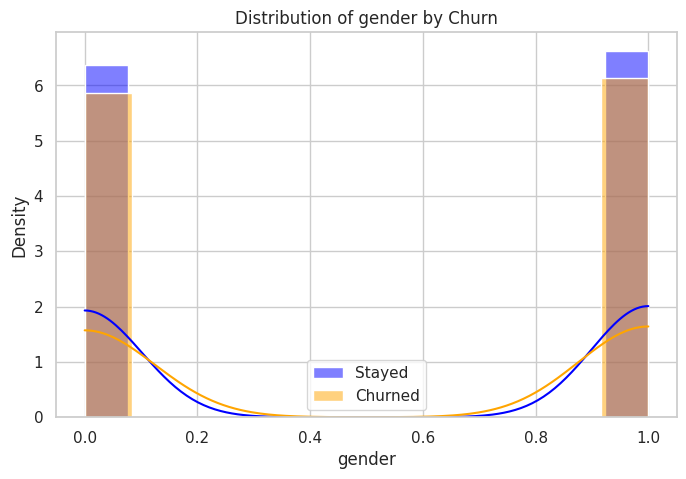

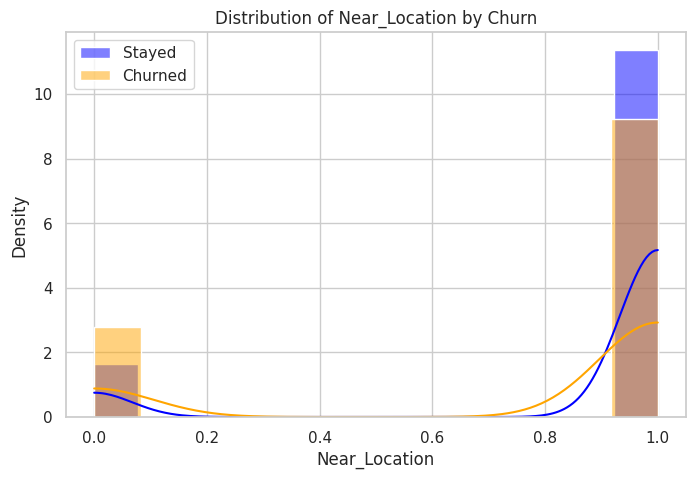

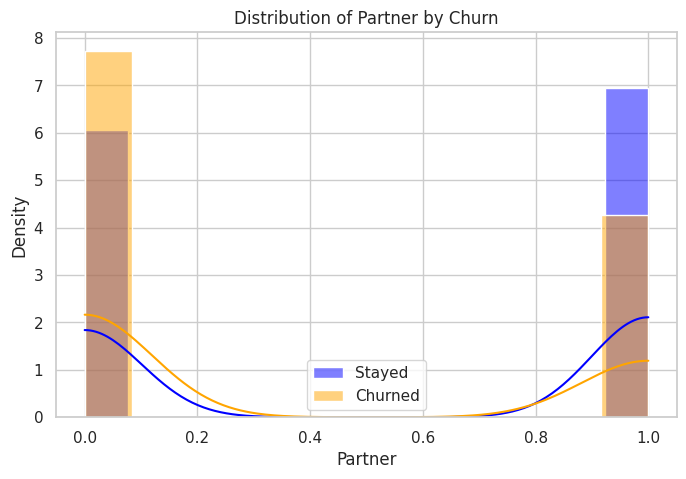

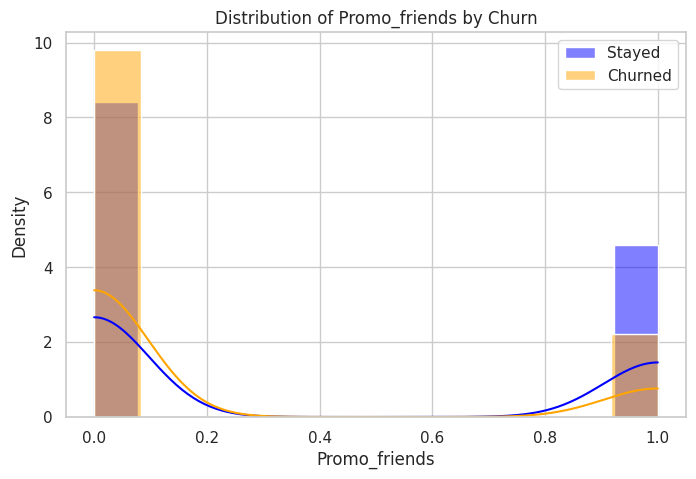

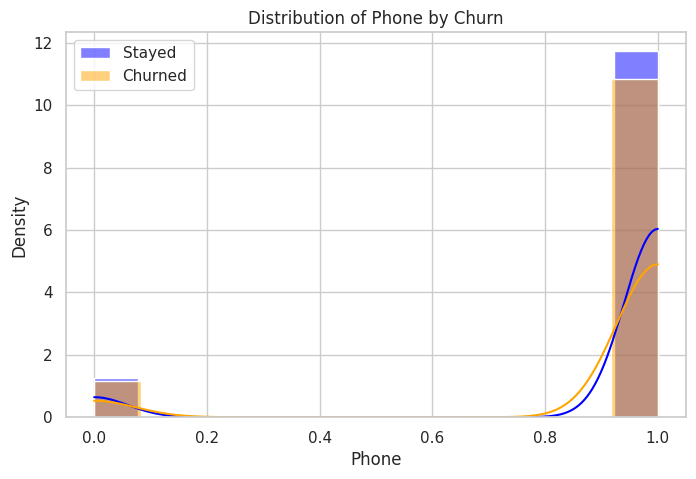

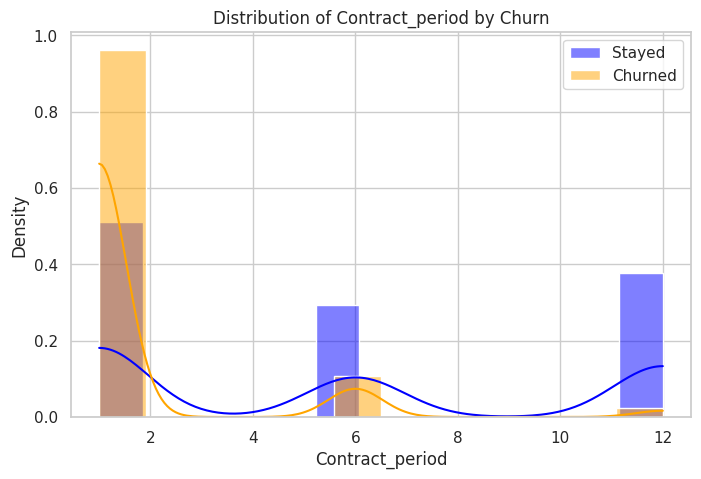

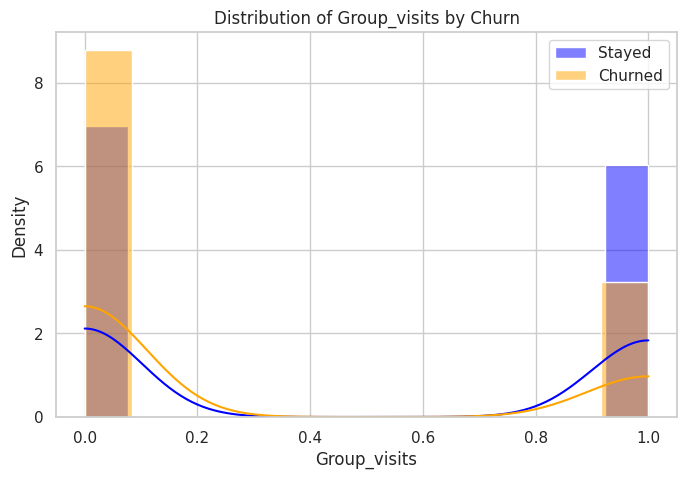

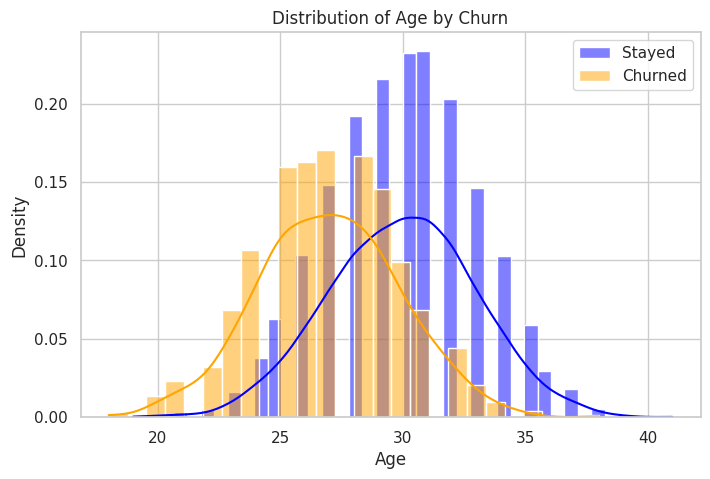

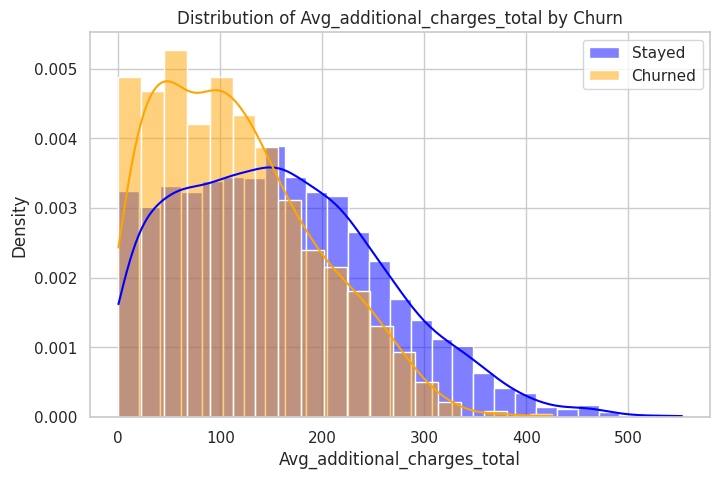

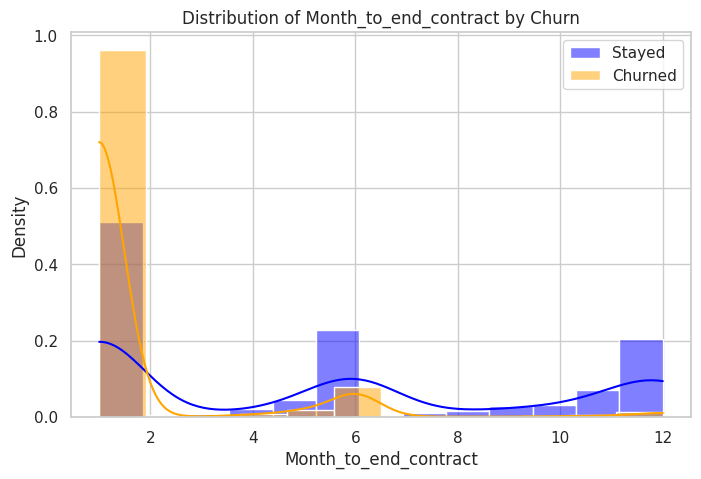

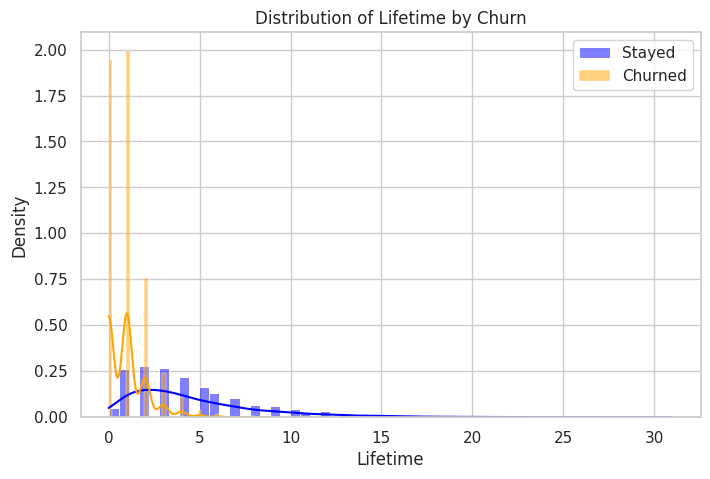

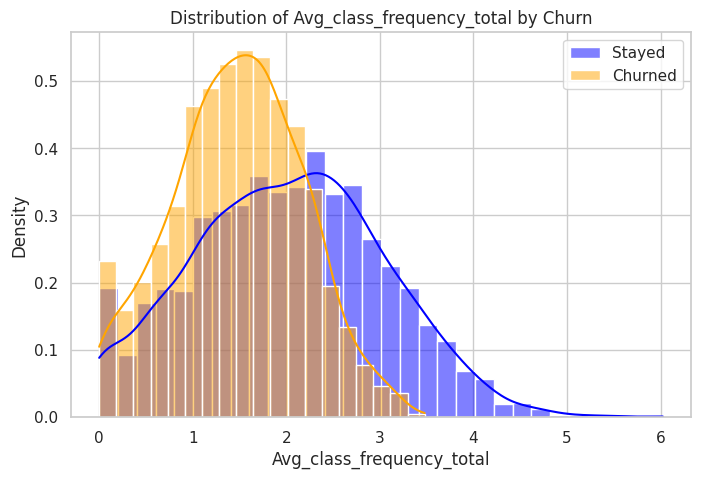

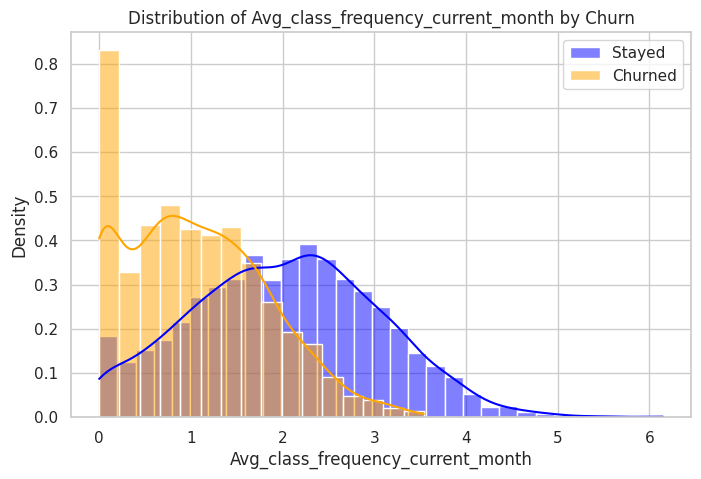

In [8]:
# Histogramas por variable
for column in gym.drop('Churn', axis=1).columns:
    plt.figure(figsize=(8, 5))
    sns.histplot(stayed[column], color='blue', label='Stayed', kde=True, stat='density')
    sns.histplot(churned[column], color='orange', label='Churned', kde=True, stat='density')
    plt.title(f'Distribution of {column} by Churn')
    plt.legend()
    plt.show()

### Interpretación general de las distribuciones por cancelación

Las gráficas comparan la distribución de cada característica entre dos grupos de clientes: quienes permanecieron activos y quienes cancelaron su membresía. En general, se observa que las variables demográficas, como `gender`, no muestran diferencias importantes entre ambos grupos, por lo que no parecen ser factores determinantes para explicar la cancelación.

Sin embargo, las variables relacionadas con el comportamiento del cliente y el tipo de contrato sí presentan diferencias más claras. Los clientes que cancelaron tienden a concentrarse en contratos cortos, especialmente de 1 mes, tienen menos meses restantes de contrato y muestran una menor antigüedad en el gimnasio (`Lifetime`). Esto indica que los clientes nuevos o con contratos de corto plazo tienen mayor riesgo de cancelar.

También se observa que la frecuencia de visitas es un factor muy relevante. Los clientes que permanecieron activos presentan una mayor frecuencia promedio de visitas, tanto a lo largo de toda su relación con el gimnasio como durante el mes actual. En cambio, los clientes que cancelaron muestran una frecuencia menor, especialmente en `Avg_class_frequency_current_month`, donde muchos tienen niveles de asistencia muy bajos. Esto sugiere que una disminución reciente en las visitas puede ser una señal temprana de posible cancelación.

Además, los clientes que permanecen suelen tener mayor participación en clases grupales, mayor gasto en servicios adicionales y mayor probabilidad de pertenecer a empresas asociadas o haberse inscrito mediante promociones de amigos. Estos elementos pueden interpretarse como señales de mayor compromiso con el gimnasio.

En conclusión, las distribuciones muestran que la cancelación está más asociada con variables de comportamiento y membresía que con variables demográficas. Los clientes con mayor riesgo de cancelación suelen ser aquellos con poca antigüedad, contratos cortos, baja frecuencia de visitas, menor participación en actividades grupales y menor consumo de servicios adicionales.


2.4 Matriz de correlación

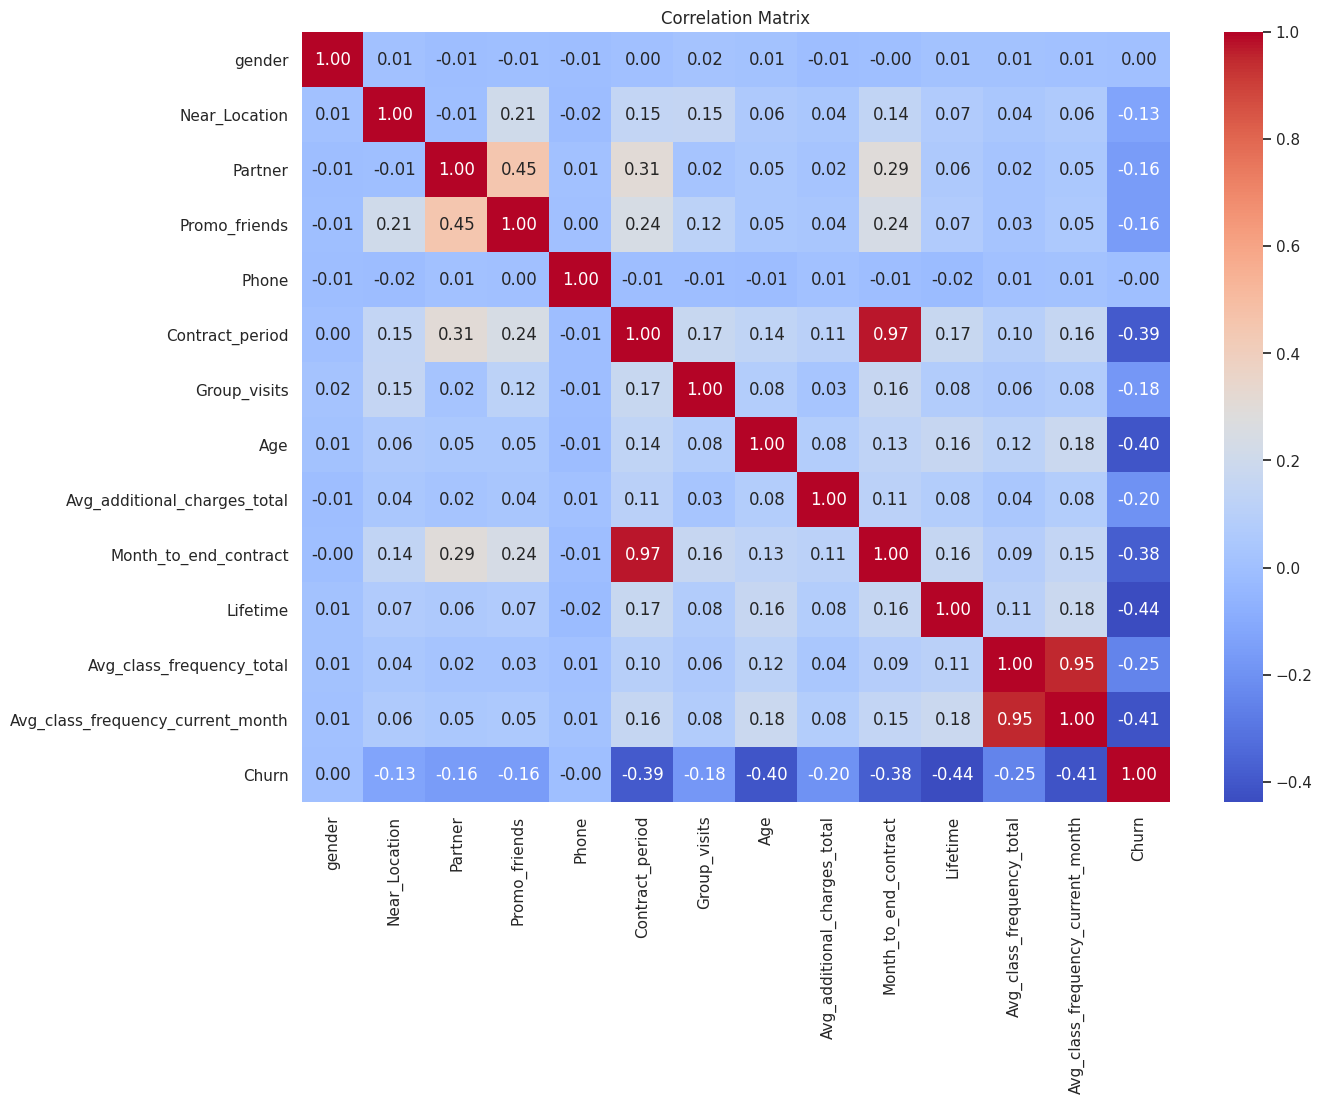

In [9]:
# Matriz de correlación
corr_matrix = gym.corr()

plt.figure(figsize=(14, 10))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

### Interpretación de la matriz de correlación

La matriz de correlación permite identificar qué variables tienen una relación más fuerte con la cancelación (`Churn`) y también detectar posibles relaciones entre las características del dataset.

En general, la mayoría de las variables presentan una correlación negativa con `Churn`, lo cual significa que, cuando estas variables aumentan, la probabilidad de cancelación tiende a disminuir. Las variables con mayor relación negativa con la cancelación son `Lifetime` (-0.44), `Avg_class_frequency_current_month` (-0.41), `Age` (-0.40), `Contract_period` (-0.39) y `Month_to_end_contract` (-0.38). Esto indica que los clientes con mayor antigüedad, mayor frecuencia de visitas en el mes actual, mayor edad y contratos más largos tienen menor probabilidad de abandonar el gimnasio.

También se observa que `Avg_class_frequency_current_month` y `Avg_class_frequency_total` tienen una correlación muy alta entre sí, de 0.95. Esto es esperado, ya que ambas variables miden la frecuencia de asistencia del cliente, una durante el mes actual y otra a lo largo de todo su historial. De forma similar, `Contract_period` y `Month_to_end_contract` tienen una correlación muy alta de 0.97, lo cual indica que los clientes con contratos más largos también suelen tener más tiempo restante antes de que termine su membresía.

Por otro lado, variables como `gender` y `Phone` prácticamente no tienen correlación con `Churn`, por lo que no parecen aportar mucha información para explicar la cancelación. Variables como `Partner`, `Promo_friends`, `Group_visits` y `Avg_additional_charges_total` sí muestran una relación negativa con la cancelación, aunque más moderada.

En conclusión, la matriz confirma que los factores más relacionados con la retención son la antigüedad del cliente, la frecuencia de asistencia, la duración del contrato y los meses restantes de membresía. Esto coincide con lo observado previamente en las distribuciones: los clientes más comprometidos con el gimnasio y con contratos más largos tienden a cancelar menos.


### 3. Modelo para predecir cancelación

3.1 Separar características y variable objetivo

In [10]:
# Matriz de características y variable objetivo
X = gym.drop('Churn', axis=1)
y = gym['Churn']

In [11]:
# División en entrenamiento y validación
X_train, X_valid, y_train, y_valid = train_test_split(
    X, y, test_size=0.2, random_state=0
)

En esta etapa se separó la variable objetivo `Churn` del resto de características. Posteriormente, los datos se dividieron en conjuntos de entrenamiento y validación con una proporción de 80% y 20%, respectivamente. Esta división permite entrenar los modelos con una parte de los datos y evaluar su desempeño con datos que el modelo no vio durante el entrenamiento.

3.2 Estandarizar los datos

Para regresión logística es recomendable estandarizar.

In [12]:
# Crear y entrenar el escalador
scaler = StandardScaler()
scaler.fit(X_train)

# Transformar entrenamiento y validación
X_train_st = scaler.transform(X_train)
X_valid_st = scaler.transform(X_valid)

Antes de entrenar la regresión logística, las características fueron estandarizadas con `StandardScaler`. Esto es recomendable para modelos lineales, ya que ayuda a que las variables estén en una escala comparable. Para el bosque aleatorio no es estrictamente necesario estandarizar, por lo que se entrenó con los datos originales.

3.3 Entrenar regresión logística

In [13]:
# Modelo de regresión logística
log_model = LogisticRegression(random_state=0)

# Entrenar modelo
log_model.fit(X_train_st, y_train)

# Predicciones
log_predictions = log_model.predict(X_valid_st)

In [14]:
# Métricas de regresión logística
print('Regresión logística')
print('Accuracy: {:.2f}'.format(accuracy_score(y_valid, log_predictions)))
print('Precision: {:.2f}'.format(precision_score(y_valid, log_predictions)))
print('Recall: {:.2f}'.format(recall_score(y_valid, log_predictions)))

Regresión logística
Accuracy: 0.92
Precision: 0.85
Recall: 0.83


3.4 Entrenar bosque aleatorio

In [15]:
# Modelo de bosque aleatorio
rf_model = RandomForestClassifier(random_state=0)

# Entrenar modelo
rf_model.fit(X_train, y_train)

# Predicciones
rf_predictions = rf_model.predict(X_valid)

In [16]:
# Métricas de bosque aleatorio
print('Bosque aleatorio')
print('Accuracy: {:.2f}'.format(accuracy_score(y_valid, rf_predictions)))
print('Precision: {:.2f}'.format(precision_score(y_valid, rf_predictions)))
print('Recall: {:.2f}'.format(recall_score(y_valid, rf_predictions)))

Bosque aleatorio
Accuracy: 0.92
Precision: 0.84
Recall: 0.82


### Comparación de modelos de clasificación

Se entrenaron dos modelos de clasificación binaria para predecir la cancelación de clientes: regresión logística y bosque aleatorio. Ambos modelos obtuvieron un desempeño muy similar en el conjunto de validación.

La regresión logística alcanzó una exactitud de 0.92, una precisión de 0.85 y un recall de 0.83. Esto significa que el modelo clasifica correctamente aproximadamente el 92% de los casos, y que, cuando predice que un cliente va a cancelar, acierta en el 85% de las ocasiones. Además, identifica correctamente alrededor del 83% de los clientes que realmente cancelaron.

El modelo de bosque aleatorio también obtuvo una exactitud de 0.92, con una precisión de 0.84 y un recall de 0.82. Aunque su desempeño es muy cercano al de la regresión logística, sus métricas de precisión y recall son ligeramente menores.

Con base en estos resultados, la regresión logística tuvo un desempeño ligeramente mejor para este conjunto de validación. Además, al ser un modelo más interpretable, puede ser útil para entender qué factores influyen en la cancelación. Por lo tanto, para este caso se podría seleccionar la regresión logística como el modelo principal, aunque ambos modelos muestran una calidad predictiva adecuada.

### 4. Crear clústeres de clientes

4.1 Separar datos sin la columna Churn

In [17]:
# Dataset para clustering sin la variable objetivo
X_cluster = gym.drop('Churn', axis=1)

In [18]:
# Estandarizar datos
scaler = StandardScaler()
X_cluster_st = scaler.fit_transform(X_cluster)

4.2 Dendrograma

In [19]:
# Crear matriz de distancias
linked = linkage(X_cluster_st, method='ward')

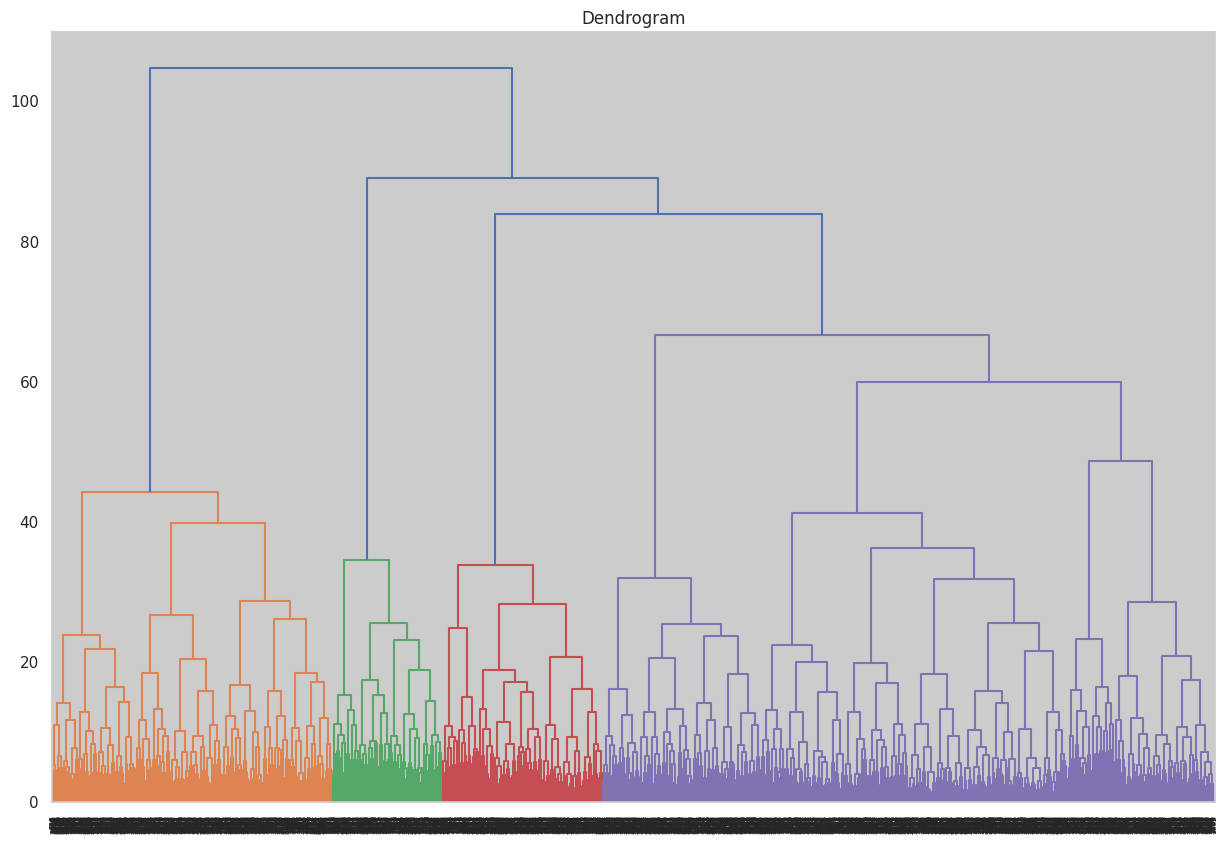

In [20]:
# Trazar dendrograma
plt.figure(figsize=(15, 10))
dendrogram(linked, orientation='top')
plt.title('Dendrogram')
plt.show()

### Interpretación del dendrograma

El dendrograma muestra cómo se agrupan los clientes de acuerdo con la similitud de sus características estandarizadas. Cada unión representa la combinación de observaciones o grupos de clientes similares, y la altura de las ramas indica qué tan diferentes son los grupos que se están uniendo.

En el gráfico se observan varios grupos diferenciados, aunque no existe una única separación perfectamente clara. Aun así, visualmente se pueden distinguir aproximadamente entre 4 y 5 agrupaciones principales. Para mantener consistencia con las instrucciones del proyecto, se utilizó K-Means con 5 clústeres. Esta decisión permite comparar los segmentos de clientes y analizar cuáles presentan mayor o menor riesgo de cancelación.

4.3 Entrenar K-Means con 5 clústeres

In [21]:
# Modelo K-Means con 5 clústeres
km = KMeans(n_clusters=5, random_state=0)

# Predecir clústeres
labels = km.fit_predict(X_cluster_st)

# Agregar clúster al dataset original
gym['cluster'] = labels

gym.head()

,gender,Near_Location,Partner,Promo_friends,Phone,Contract_period,Group_visits,Age,Avg_additional_charges_total,Month_to_end_contract,Lifetime,Avg_class_frequency_total,Avg_class_frequency_current_month,Churn,cluster
0,1,1,1,1,0,6,1,29,14.227470,5.0,3,0.020398,0.000000,0,1
1,0,1,0,0,1,12,1,31,113.202938,12.0,7,1.922936,1.910244,0,0
2,0,1,1,0,1,1,0,28,129.448479,1.0,2,1.859098,1.736502,0,3
3,0,1,1,1,1,12,1,33,62.669863,12.0,2,3.205633,3.357215,0,0
4,1,1,1,1,1,1,0,26,198.362265,1.0,3,1.113884,1.120078,0,3


4.4 Valores medios por clúster

In [22]:
# Valores promedio por clúster
gym.groupby('cluster').mean()

,gender,Near_Location,Partner,Promo_friends,Phone,Contract_period,Group_visits,Age,Avg_additional_charges_total,Month_to_end_contract,Lifetime,Avg_class_frequency_total,Avg_class_frequency_current_month,Churn
cluster,,,,,,,,,,,,,,
0,0.502970,0.959406,0.783168,0.574257,1.000000,10.889109,0.542574,29.982178,160.761016,9.954455,4.736634,1.982055,1.974789,0.027723
1,0.522078,0.862338,0.470130,0.306494,0.000000,4.787013,0.425974,29.301299,143.957664,4.475325,3.924675,1.847220,1.716369,0.267532
2,0.495050,0.000000,0.463366,0.079208,1.000000,2.352475,0.215842,28.477228,135.457501,2.198020,2.809901,1.660461,1.477324,0.443564
3,0.485737,1.000000,0.350238,0.240095,1.000000,1.948494,0.341521,28.167987,131.622204,1.856577,2.440571,1.247634,1.012983,0.514263
4,0.559666,0.976134,0.356802,0.230310,0.998807,2.669451,0.473747,30.125298,161.657905,2.459427,4.898568,2.852002,2.850161,0.068019


### Interpretación de los valores promedio por clúster

El análisis de los valores promedio por clúster permite identificar distintos perfiles de clientes dentro del gimnasio.

El clúster 0 agrupa clientes con contratos largos, mayor cantidad de meses restantes de contrato, alta participación en promociones de amigos y alta proporción de clientes asociados a empresas partner. Este grupo parece representar clientes con mayor compromiso contractual y comercial con el gimnasio.

El clúster 1 incluye clientes con contratos de duración media y una frecuencia de visitas moderada. Una característica particular de este grupo es que no registraron teléfono, lo cual puede dificultar las acciones de contacto y retención.

El clúster 2 concentra clientes que no viven ni trabajan cerca del gimnasio. Además, tienen contratos cortos, baja participación en clases grupales y menor frecuencia de visitas en comparación con los grupos más leales. Esta distancia física puede representar una barrera para mantener una asistencia constante.

El clúster 3 incluye clientes que sí están cerca del gimnasio, pero presentan contratos cortos, menor antigüedad y menor frecuencia de visitas. Este grupo parece representar clientes nuevos o poco comprometidos, por lo que puede ser vulnerable a la cancelación.

El clúster 4 muestra características más favorables: clientes con mayor edad promedio, mayor frecuencia de visitas, mayor gasto en servicios adicionales y mayor antigüedad. Este grupo parece ser uno de los segmentos más leales y comprometidos con el gimnasio.

4.5 Distribuciones por clúster

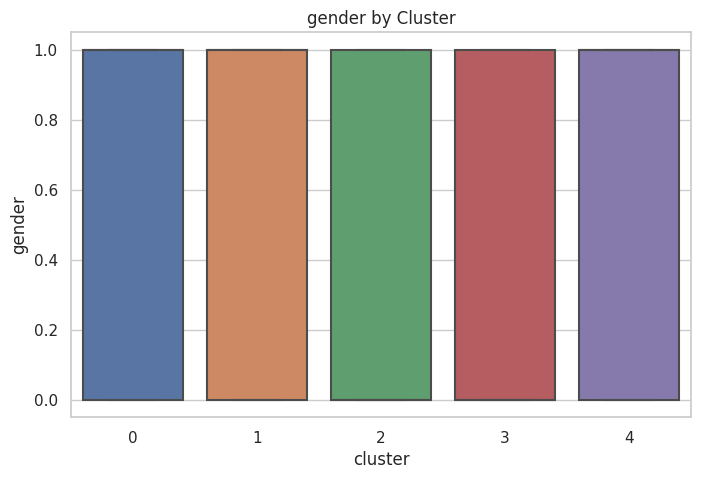

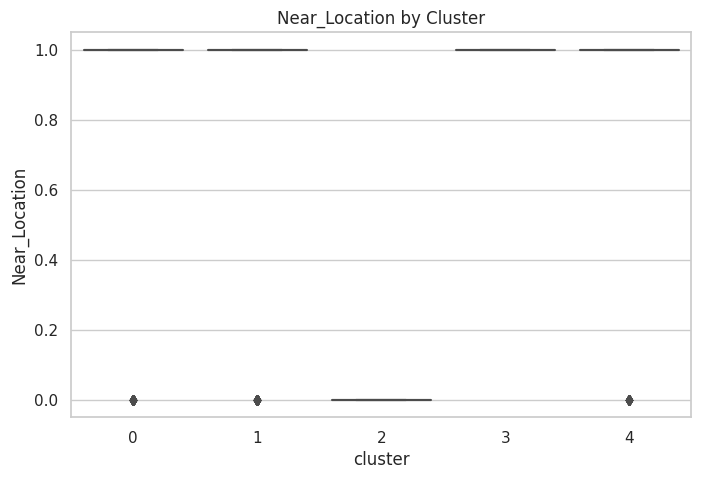

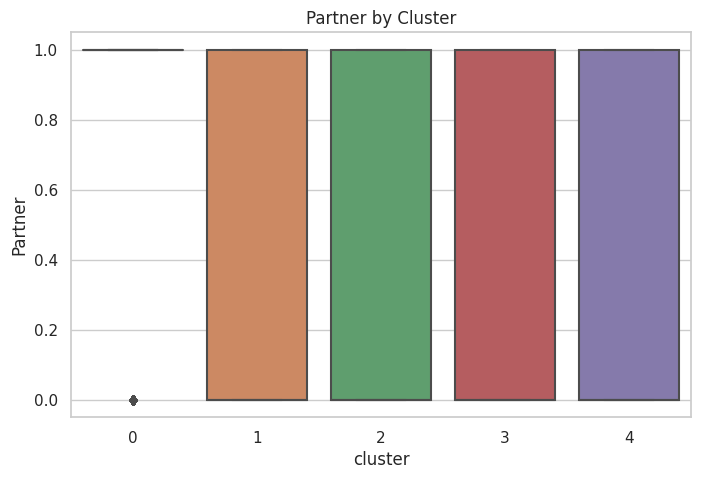

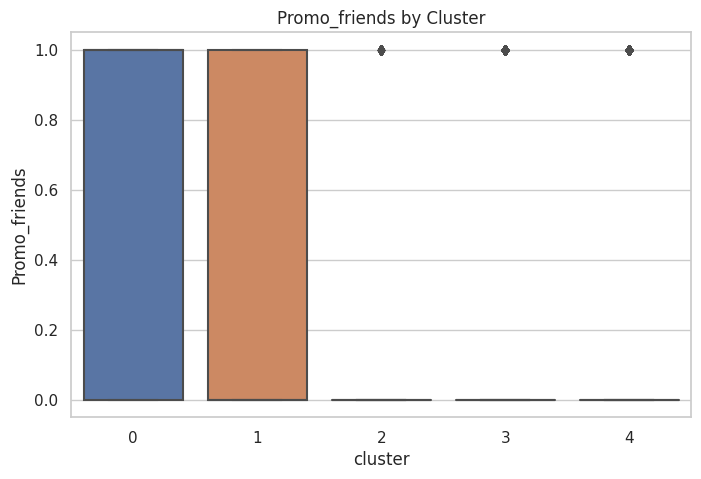

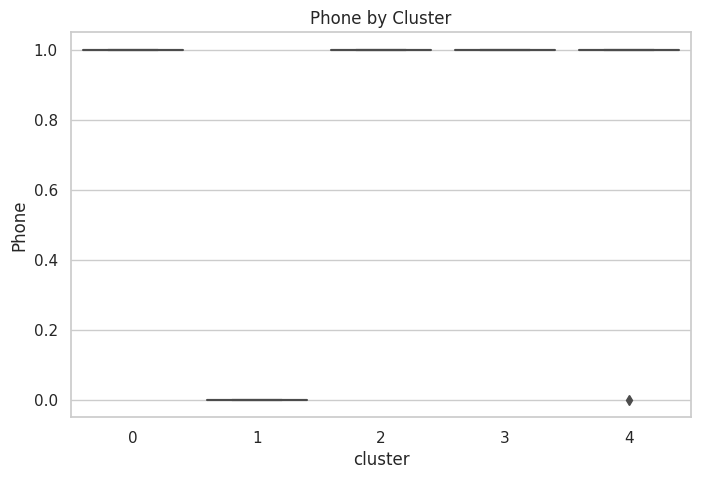

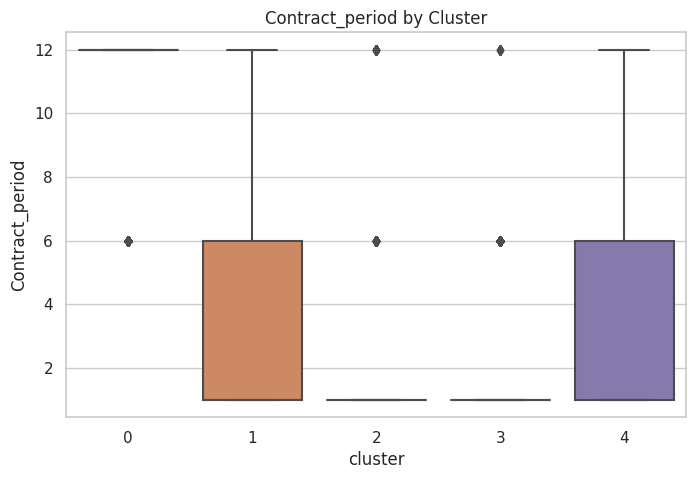

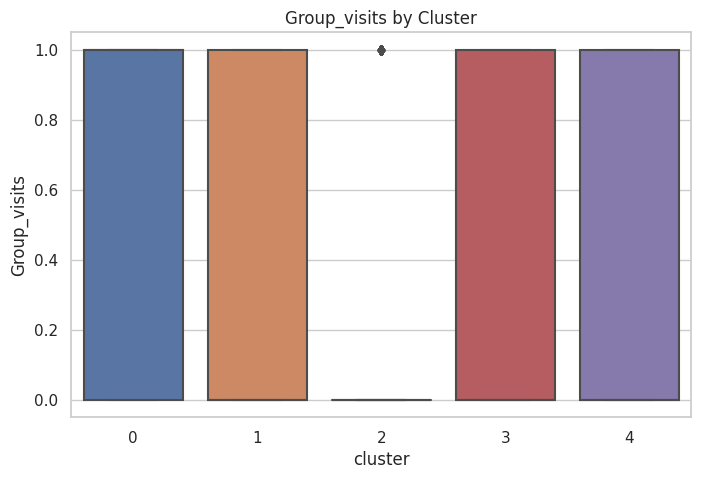

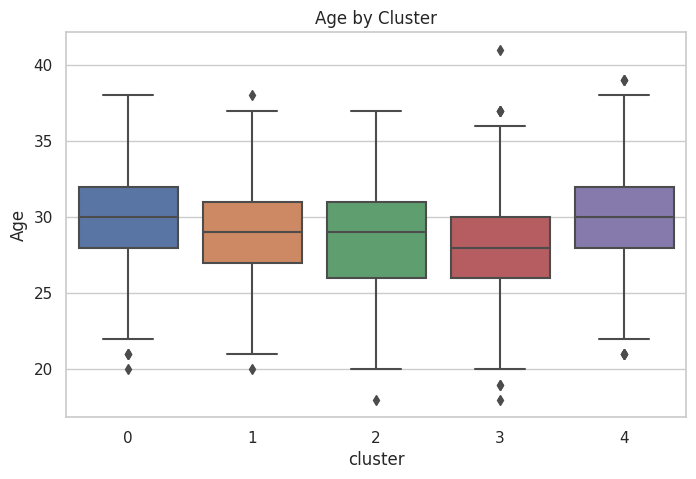

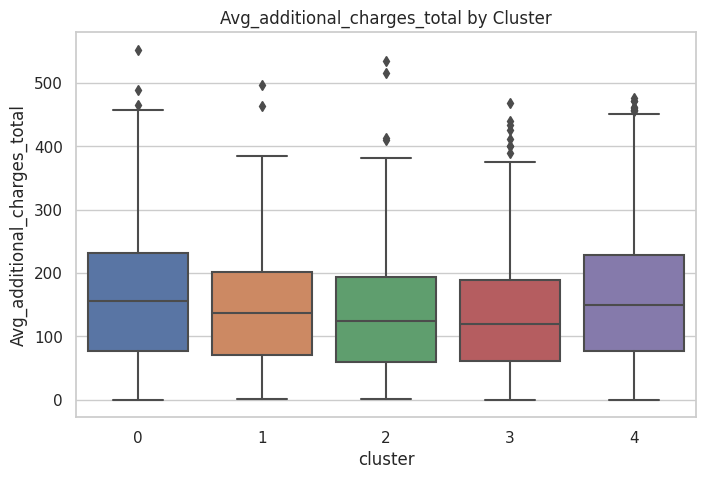

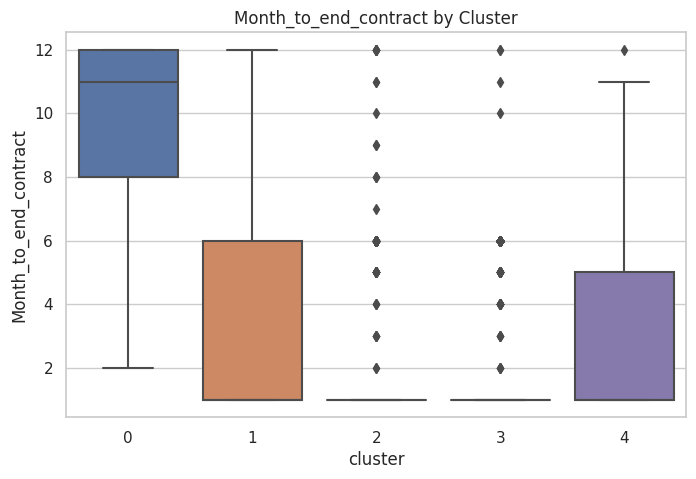

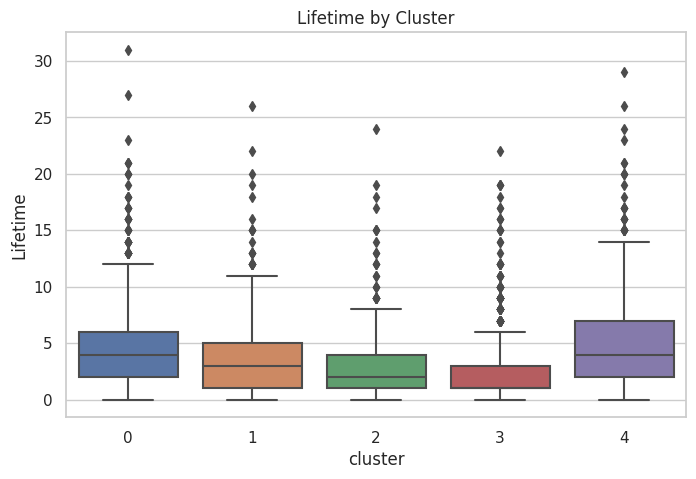

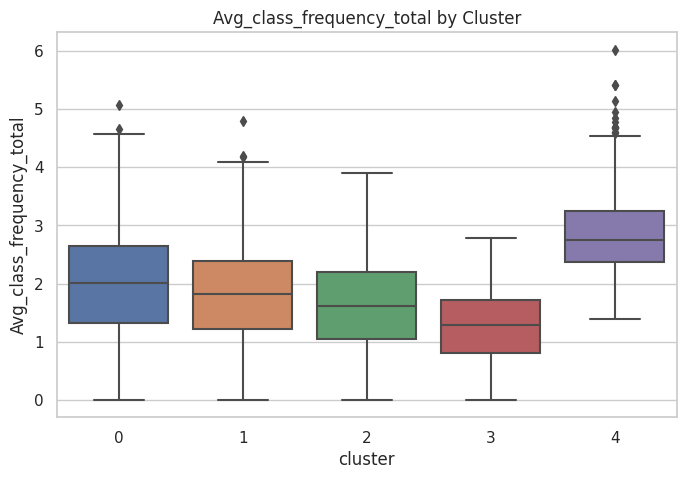

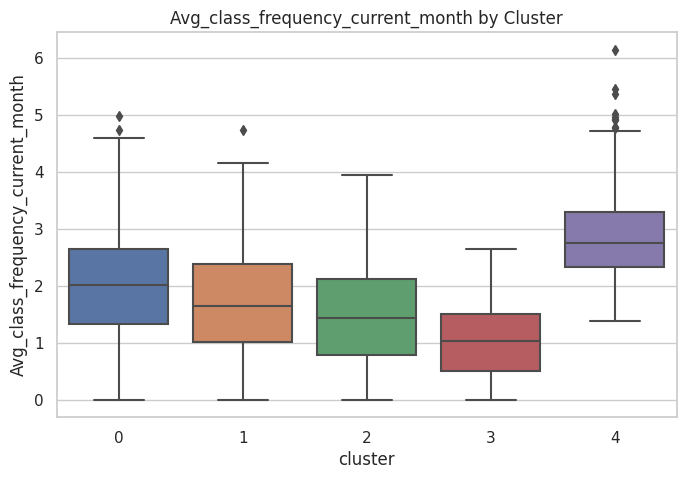

In [23]:
# Distribuciones de características por clúster
for column in gym.drop(['Churn', 'cluster'], axis=1).columns:
    plt.figure(figsize=(8, 5))
    sns.boxplot(x='cluster', y=column, data=gym)
    plt.title(f'{column} by Cluster')
    plt.show()

### Interpretación general de las distribuciones por clúster

Las distribuciones por clúster muestran diferencias importantes en el comportamiento y perfil de los clientes. Algunas variables, como `gender`, no presentan diferencias relevantes entre los grupos, por lo que no parecen ser determinantes para segmentar a los clientes.

En cambio, variables como `Near_Location`, `Contract_period`, `Month_to_end_contract`, `Lifetime`, `Avg_class_frequency_total` y `Avg_class_frequency_current_month` muestran diferencias claras entre clústeres. Esto indica que la segmentación está fuertemente influenciada por la cercanía al gimnasio, la duración del contrato, la antigüedad del cliente y la frecuencia de asistencia.

Los clústeres con contratos más largos y más meses restantes de membresía tienden a mostrar mayor estabilidad. Por ejemplo, el clúster 0 presenta contratos más extensos y mayor tiempo restante de contrato. En contraste, los clústeres 2 y 3 se concentran en contratos cortos, lo cual puede representar mayor riesgo de cancelación.

La frecuencia de visitas también diferencia claramente a los grupos. El clúster 4 destaca por tener la frecuencia de asistencia más alta, tanto históricamente como durante el mes actual. Esto sugiere que sus integrantes tienen un alto nivel de compromiso con el gimnasio. Por el contrario, el clúster 3 presenta las frecuencias de visita más bajas, lo cual puede indicar un mayor riesgo de abandono.

La variable `Lifetime` también es relevante: los clientes con menor antigüedad se concentran principalmente en clústeres con mayor riesgo potencial, mientras que los clientes con más tiempo en el gimnasio se encuentran en grupos más estables. Esto confirma que los primeros meses de relación con el cliente son críticos para la retención.

En general, los clústeres permiten identificar perfiles diferenciados de clientes. Algunos grupos reflejan usuarios más comprometidos y leales, mientras que otros agrupan clientes con menor frecuencia de visitas, contratos cortos o menor antigüedad, características asociadas con una mayor probabilidad de cancelación.

4.6 Tasa de cancelación por clúster

In [24]:
# Tasa de cancelación por clúster
churn_rate_by_cluster = gym.groupby('cluster')['Churn'].mean()

churn_rate_by_cluster

cluster
0    0.027723
1    0.267532
2    0.443564
3    0.514263
4    0.068019
Name: Churn, dtype: float64

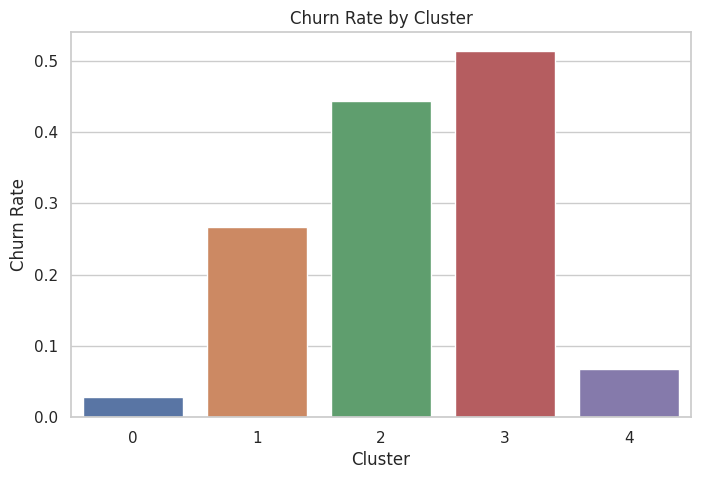

In [25]:
# Visualizar tasa de cancelación por clúster
plt.figure(figsize=(8, 5))
sns.barplot(x=churn_rate_by_cluster.index, y=churn_rate_by_cluster.values)
plt.title('Churn Rate by Cluster')
plt.xlabel('Cluster')
plt.ylabel('Churn Rate')
plt.show()

### Interpretación de la tasa de cancelación por clúster

La tasa de cancelación varía de forma importante entre los clústeres, lo que confirma que los grupos de clientes tienen comportamientos diferentes en términos de retención.

El clúster 3 presenta la tasa de cancelación más alta, con aproximadamente 51.4%. Esto lo convierte en el grupo de mayor riesgo. Este clúster se caracteriza por clientes con contratos cortos, menor antigüedad y baja frecuencia de visitas. Por lo tanto, representa un segmento prioritario para acciones de retención.

El clúster 2 también muestra una tasa de cancelación elevada, cercana al 44.4%. Este grupo incluye clientes que no viven o trabajan cerca del gimnasio, con baja participación en clases grupales y menor frecuencia de asistencia. La distancia al gimnasio y el bajo nivel de interacción pueden estar contribuyendo a su mayor probabilidad de abandono.

El clúster 1 tiene una tasa de cancelación intermedia, de aproximadamente 26.8%. Aunque no es el grupo con mayor riesgo, todavía representa un segmento que debe monitorearse, especialmente porque incluye clientes con información de contacto limitada o menor compromiso que los grupos más leales.

En contraste, los clústeres 0 y 4 presentan las tasas de cancelación más bajas, con aproximadamente 2.8% y 6.8%, respectivamente. Estos grupos parecen ser los más leales. El clúster 0 destaca por contratos largos y más meses restantes de membresía, mientras que el clúster 4 se caracteriza por una mayor frecuencia de visitas, mayor gasto adicional y mayor antigüedad.

En conclusión, los clústeres 2 y 3 deben considerarse los principales grupos objetivo para estrategias de retención, mientras que los clústeres 0 y 4 representan perfiles de clientes más comprometidos que pueden servir como referencia para diseñar estrategias que aumenten la lealtad en otros segmentos.

### Conclusión del análisis de clústeres

El análisis de clústeres permitió identificar cinco perfiles de clientes con comportamientos claramente diferenciados. Los grupos con mayor riesgo de cancelación son los clústeres 3 y 2, debido a sus altas tasas de abandono, contratos cortos, menor antigüedad y menor frecuencia de visitas. En cambio, los clústeres 0 y 4 presentan los perfiles más leales, asociados con contratos más largos, mayor frecuencia de asistencia, mayor gasto en servicios adicionales y mayor compromiso con el gimnasio.

Estos resultados muestran que la estrategia de retención debe ser segmentada. No todos los clientes tienen el mismo nivel de riesgo ni responden a los mismos factores. Por ello, Model Fitness debería enfocar sus esfuerzos en clientes nuevos, con baja frecuencia de asistencia, contratos cortos o baja interacción con los servicios del gimnasio.

## 5. Conclusiones y recomendaciones

El análisis de los datos de Model Fitness permitió identificar patrones importantes relacionados con la cancelación de clientes. El dataset contiene 4000 clientes y no presenta valores ausentes, por lo que fue posible trabajar directamente con la información disponible.

Durante el análisis exploratorio se observó que la cancelación está más relacionada con el comportamiento del cliente y las características de su membresía que con variables demográficas. Variables como `gender` y `Phone` no mostraron diferencias relevantes entre clientes que cancelaron y clientes que permanecieron activos. En cambio, variables como `Contract_period`, `Month_to_end_contract`, `Lifetime`, `Avg_class_frequency_total` y `Avg_class_frequency_current_month` mostraron una relación más clara con la cancelación.

Los clientes que cancelaron tenían, en promedio, contratos más cortos, menor cantidad de meses restantes de contrato, menor antigüedad y menor frecuencia de visitas. Por ejemplo, los clientes que se quedaron tenían un `Lifetime` promedio de aproximadamente 4.71 meses, mientras que los clientes que cancelaron tenían un promedio cercano a 0.99 meses. También se observó que los clientes que permanecieron activos asistían con mayor frecuencia al gimnasio, tanto históricamente como durante el mes actual.

Se entrenaron dos modelos de clasificación para predecir la cancelación: regresión logística y bosque aleatorio. Ambos modelos obtuvieron un desempeño similar, con una exactitud de 0.92. Sin embargo, la regresión logística obtuvo resultados ligeramente mejores en precisión y recall, con una precisión de 0.85 y un recall de 0.83, frente a 0.84 y 0.82 del bosque aleatorio. Por esta razón, la regresión logística puede considerarse el modelo más conveniente para este caso, especialmente porque también es más fácil de interpretar.

El análisis de clústeres permitió identificar cinco segmentos de clientes con distintos niveles de riesgo. Los clústeres 3 y 2 fueron los más propensos a cancelar, con tasas de cancelación aproximadas de 51.4% y 44.4%, respectivamente. Estos grupos se caracterizan por contratos cortos, menor antigüedad, menor frecuencia de visitas y, en algunos casos, menor cercanía al gimnasio. Por otro lado, los clústeres 0 y 4 fueron los más leales, con tasas de cancelación de aproximadamente 2.8% y 6.8%.

Con base en estos resultados, se recomienda que Model Fitness enfoque sus estrategias de retención en los clientes nuevos, con baja frecuencia de visitas, contratos cortos y poca interacción con los servicios del gimnasio. También sería conveniente incentivar contratos de mayor duración, promover clases grupales y diseñar campañas específicas para clientes que muestran una caída en su asistencia durante el mes actual.

### Recomendaciones específicas

1. Implementar campañas de retención temprana para clientes con bajo `Lifetime`, especialmente durante los primeros meses de membresía.

2. Monitorear la variable `Avg_class_frequency_current_month` para detectar clientes cuya frecuencia de visitas disminuya y contactarlos antes de que cancelen.

3. Promover contratos de 6 y 12 meses mediante descuentos, beneficios adicionales o paquetes corporativos, ya que los contratos largos se asocian con menor cancelación.

4. Incentivar la participación en clases grupales y servicios adicionales para aumentar el compromiso del cliente con el gimnasio.

5. Priorizar acciones de marketing y seguimiento para los clústeres 2 y 3, ya que presentan las tasas más altas de cancelación.